# Predict Student`s Dropout and Academic Success

## Step1: Data Preprocessing

In [198]:
import numpy as np
from IPython.display import HTML
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

In [189]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### 1(a) Data Ingestion

In [190]:
data = pd.read_csv("predict+students+dropout+and+academic+success/data.csv", sep=";")

In [191]:
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### 1(b) Data Exploration

In [192]:
data.shape, data["Target"].unique()

((4424, 37), array(['Dropout', 'Graduate', 'Enrolled'], dtype=object))

### Key Findings from Initial Data Exploration:

1. Dataset dimensions:
   - Features: 36
   - Samples: 4424 rows

2. Target Variable Categories:
   - Dropout: Students who left school
   - Graduate: Students who completed their studies
   - Enrolled: Students who maintained enrollment

In [193]:
print(data.columns)

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [195]:
# rename columns
data.columns = [["Marital status", "Application mode", "Application order", "Course", "Daytime/evening attendance",
                 "Previous qualification", "Previous qualification (grade)", "Nationality", "Mother's qualification",
                 "Father's qualification", "Mother's occupation", "Father's occupation", "Admission grade",
                 "Displaced", "Educational special needs", "Debtor", "Tuition fees up to date", "Gender",
                 "Scholarship holder", "Age at enrollment", "International", "Curricular units 1st sem (credited)",
                 "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (evaluations)",
                 "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
                 "Curricular units 1st sem (without evaluations)",
                 "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
                 "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
                 "Curricular units 2nd sem (grade)", "Curricular units 2nd sem (without evaluations)",
                 "Unemployment rate", "Inflation rate", "GDP", "Target"
                 ]]

#### Explore Demographic Data

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
    <tr><td rowspan="6" style="border:1px solid #ccc;padding:6px;text-align:left;">Demographic data</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Marital status</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Nationality</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Displaced</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Gender</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Age at enrollment</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">International</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    
  </tbody>
</table>


In [197]:
# function to convert string keys to integer keys in a dictionary
def str_to_int(str_dict):
    return {int(k): v for k, v in str_dict.items()}

In [199]:
# load mapping JSON files, manually created for data visualization purposes
 
with open('./predict+students+dropout+and+academic+success/mapping/marital_status.json', 'r') as f:
    marital_status_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/nationality.json', 'r') as f:
    nationality_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/application_mode.json', 'r') as f:
    application_mode_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/course.json', 'r') as f:
    course_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/father_occupations.json', 'r') as f:
    father_occupations_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/mother_occupations.json', 'r') as f:
    mother_occupations_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/previous_qualification.json', 'r') as f:
    previous_qualification_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/father_qualifications.json', 'r') as f:
    father_qualifications_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/mother_qualifications.json', 'r') as f:
    mother_qualifications_json = str_to_int(json.load(f))



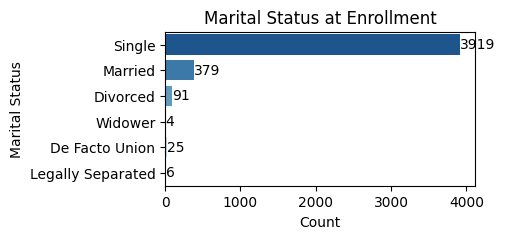

In [202]:
# Plot for Marital Status
mapped_data = data[["Marital status"]].iloc[:,0].astype(int).map(marital_status_json)

plt.figure(figsize=(4, 2))
sns.countplot(
    y=mapped_data,
    hue=mapped_data,  # assign to hue
    palette="Blues_r",
    legend=False
)

plt.title("Marital Status at Enrollment")
plt.xlabel("Count")
plt.ylabel("Marital Status")

# Show exact counts on bars
for p in plt.gca().patches:
    plt.text(
        p.get_width() + 0.3,
        p.get_y() + p.get_height() / 2,
        int(p.get_width()),
        va='center'
    )

plt.show()


The majority of students are single, followed by married and then divorced. Only a small proportion fall under categories such as de facto union, legally separated, or widowed.

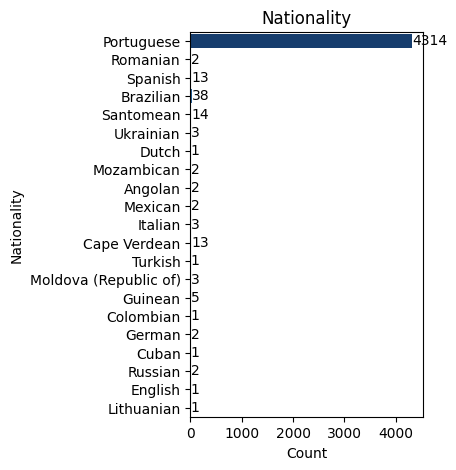

In [204]:
# Plot for Nationality
mapped_data = data[["Nationality"]].iloc[:,0].astype(int).map(nationality_json)

plt.figure(figsize=(3, 5))
sns.countplot(
    y=mapped_data,
    hue=mapped_data,  # assign to hue
    palette="Blues_r",
    legend=False
)

plt.title("Nationality")
plt.xlabel("Count")
plt.ylabel("Nationality")

# Show exact counts on bars
for p in plt.gca().patches:
    plt.text(
        p.get_width() + 0.3,
        p.get_y() + p.get_height() / 2,
        int(p.get_width()),
        va='center'
    )
plt.show()

Most of the students are from Portugese,followed by Brazilian

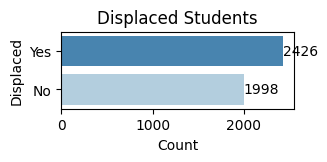

Percentage of Displaced Students: Yes: 54.84%, No: 45.16%


In [206]:
# Plot for Displaced
mapped_data = data[["Displaced"]].iloc[:,0].astype(int).map({1: 'Yes', 0: 'No'})

plt.figure(figsize=(3, 1))
sns.countplot(
    y=mapped_data,
    hue=mapped_data,  # assign to hue
    palette="Blues_r",
    legend=False
)
plt.title("Displaced Students")
plt.xlabel("Count")
plt.ylabel("Displaced")

# Show exact counts on bars
for p in plt.gca().patches:
    plt.text(
        p.get_width() + 0.3,
        p.get_y() + p.get_height() / 2,
        int(p.get_width()),
        va='center'
    )
plt.show()

# show percentage of displaced students
displaced_counts = data['Displaced'].value_counts(normalize=True) * 100
print(f"Percentage of Displaced Students: Yes: {displaced_counts[1]:.2f}%, No: {displaced_counts[0]:.2f}%")

Most of the students are displaced from their home town

In [210]:
# show percentage of Gender
data['Gender'].iloc[:,0].map({1: 'Male', 0: 'Female'}).value_counts()

(Gender,)
Female    2868
Male      1556
Name: count, dtype: int64

Most of the students are female

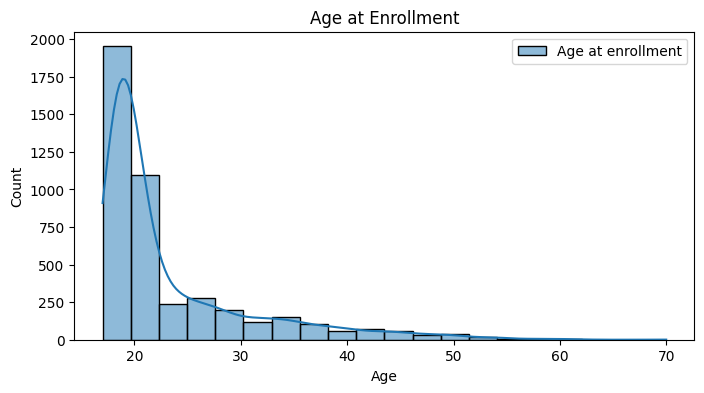

In [211]:
# Plot for Age at Enrollment
plt.figure(figsize=(8, 4))
sns.histplot(data['Age at enrollment'], bins=20, kde=True)
plt.title("Age at Enrollment")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Most students are young, while very few above the age of 30 pursue studies.

In [214]:
# show percentage of Gender
data['International'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts()

(International,)
No     4314
Yes     110
Name: count, dtype: int64

Very few students are from out of the country

#### Exploring the socio-economic data

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
    <tr><td rowspan="8" style="border:1px solid #ccc;padding:6px;text-align:left;">Socioeconomic data</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Mother’s qualification</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Father’s qualification</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Mother’s occupation</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Father’s occupation</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Educational special needs</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Debtor</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Tuition fees up to date</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Scholarship holder</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>

  </tbody>
</table>

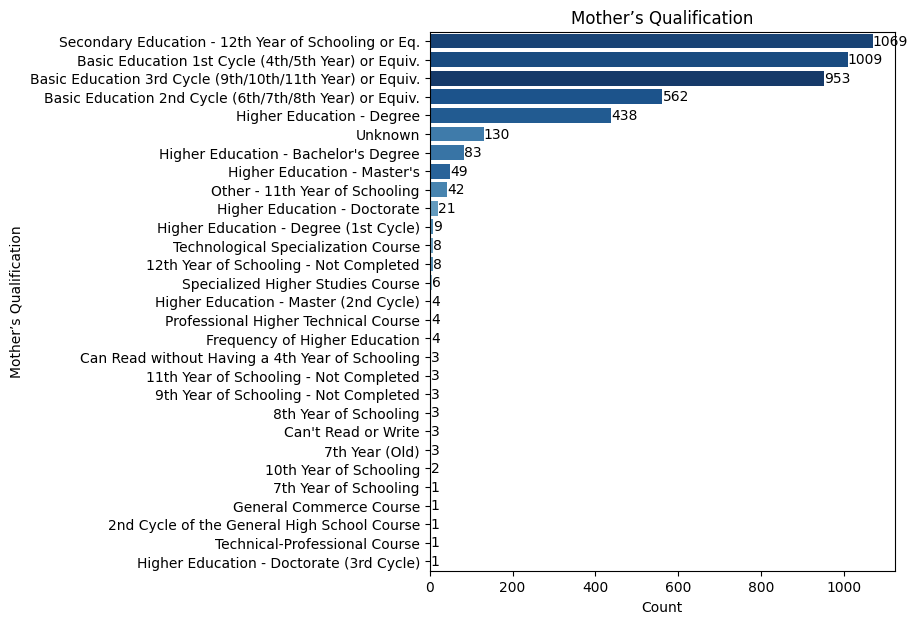

In [215]:
# Plot for Mother’s qualification
mapped_data = data[["Mother's qualification"]].iloc[:,0].astype(int).map(mother_qualifications_json)

plt.figure(figsize=(6, 7))

# Map values
mother_qual = mapped_data

# Get counts and sort (descending)
order = mother_qual.value_counts(ascending=True).index

sns.countplot(
    y=mother_qual,
    order=order,                # apply sorted order
    hue=mother_qual,            # needed for palette
    palette="Blues_r",
    legend=False
)

plt.title("Mother’s Qualification")
plt.xlabel("Count")
plt.ylabel("Mother’s Qualification")

# Show exact counts on bars
for p in plt.gca().patches:
    plt.text(
        p.get_width() + 0.3,
        p.get_y() + p.get_height() / 2,
        int(p.get_width()),
        va='center'
    )

plt.gca().invert_yaxis()
plt.show()


Most of the Mother's qualifications are Basic Educations, followed by Secondary Educations. Very few have a Degree.

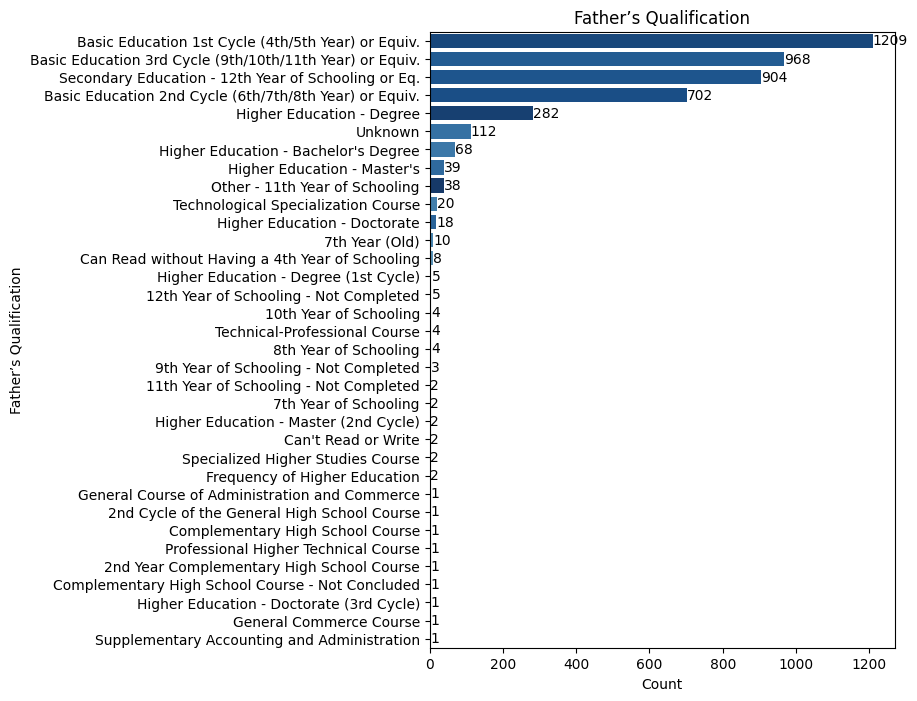

In [216]:
# Plot for Father’s qualification
mapped_data = data[["Father's qualification"]].iloc[:,0].astype(int).map(father_qualifications_json)

plt.figure(figsize=(6, 8))
# Map values
father_qual = mapped_data
# Get counts and sort (descending)
order = father_qual.value_counts(ascending=True).index

sns.countplot(
    y=father_qual,
    order=order,                # apply sorted order
    hue=father_qual,            # needed for palette
    palette="Blues_r",
    legend=False
)
plt.title("Father’s Qualification")
plt.xlabel("Count")
plt.ylabel("Father’s Qualification")
# Show exact counts on bars
for p in plt.gca().patches:
    plt.text(
        p.get_width() + 0.3,
        p.get_y() + p.get_height() / 2,
        int(p.get_width()),
        va='center'
    )
plt.gca().invert_yaxis()
plt.show()

Most of the Father's qualifications are Basic Educations, followed by Secondary Educations. Very few have a Degree.

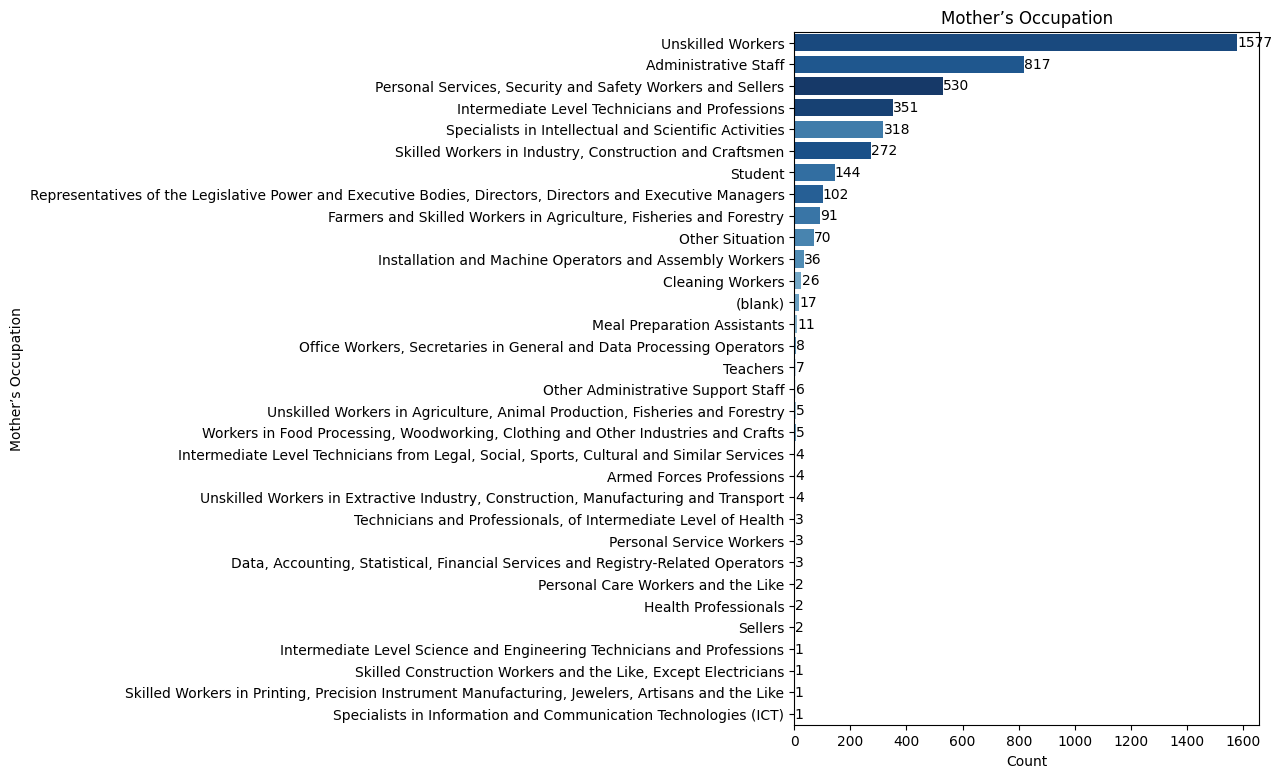

In [217]:
# Plot for Mother’s occupation
mapped_data = data[["Mother's occupation"]].iloc[:,0].astype(int).map(mother_occupations_json)

plt.figure(figsize=(6, 9))
# Map values
mother_occ = mapped_data
# Get counts and sort (descending)
order = mother_occ.value_counts(ascending=True).index
sns.countplot(
    y=mother_occ,
    order=order,                # apply sorted order
    hue=mother_occ,            # needed for palette
    palette="Blues_r",
    legend=False
)
plt.title("Mother’s Occupation")
plt.xlabel("Count")
plt.ylabel("Mother’s Occupation")
# Show exact counts on bars
for p in plt.gca().patches:
    plt.text(
        p.get_width() + 0.3,
        p.get_y() + p.get_height() / 2,
        int(p.get_width()),
        va='center'
    )
plt.gca().invert_yaxis()
plt.show()

In [219]:
# show percentage of Educational special needs
data['Educational special needs'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts(normalize=True) * 100

(Educational special needs,)
No     98.847197
Yes     1.152803
Name: proportion, dtype: float64

A very few students have Educational special needs

In [221]:
# show percentage of Debtor
data['Debtor'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts(normalize=True) * 100

(Debtor,)
No     88.630199
Yes    11.369801
Name: proportion, dtype: float64

In [222]:
# show percentage of Tuition fees up to date
data['Tuition fees up to date'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts(normalize=True) * 100

(Tuition fees up to date,)
Yes    88.065099
No     11.934901
Name: proportion, dtype: float64

In [223]:
# show percentage of Scholarship holder
data['Scholarship holder'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts(normalize=True) * 100

(Scholarship holder,)
No     75.158228
Yes    24.841772
Name: proportion, dtype: float64

#### Exploring the socio-economic data

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
    <tr><td rowspan="3" style="border:1px solid #ccc;padding:6px;text-align:left;">Economic data</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Unemployment rate</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Continuous</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Inflation rate</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Continuous</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">GDP</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Continuous</td></tr>
</tbody>
</table>

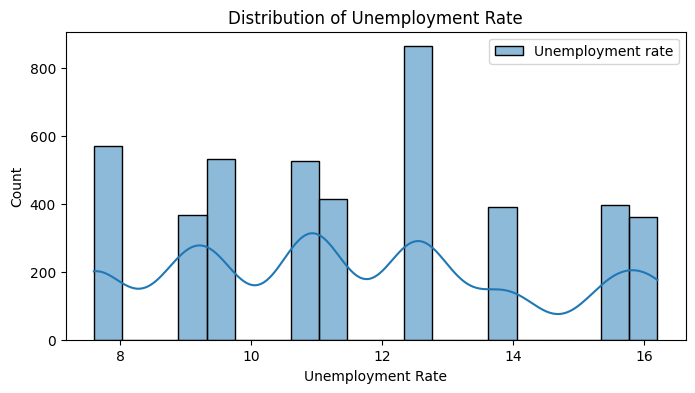

In [224]:
# Plot for Unemployment rate
plt.figure(figsize=(8, 4))

# Create histogram plot directly without sorting
sns.histplot(data['Unemployment rate'], bins=20, kde=True)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate")
plt.ylabel("Count")
plt.show()


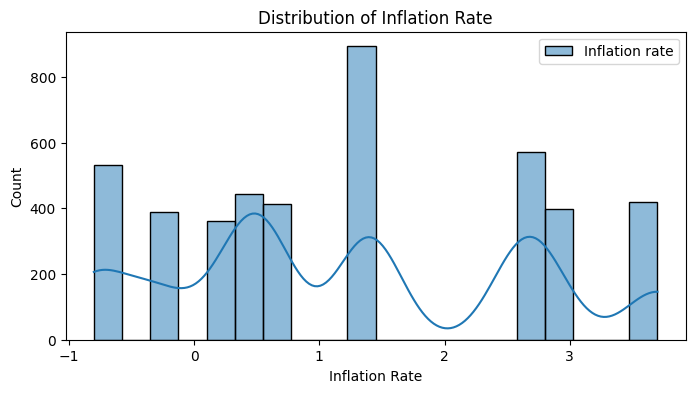

In [225]:
# Plot for Inflation rate
plt.figure(figsize=(8, 4))
# Create histogram plot directly without sorting
sns.histplot(data['Inflation rate'], bins=20, kde=True)
plt.title("Distribution of Inflation Rate")
plt.xlabel("Inflation Rate")
plt.ylabel("Count")
plt.show()

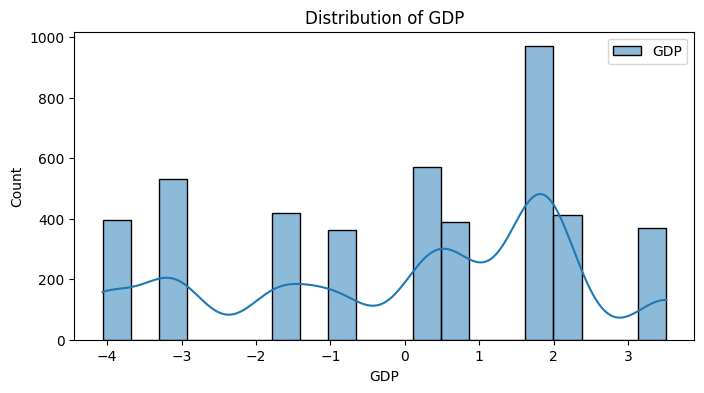

In [226]:
# Plot for GDP
plt.figure(figsize=(8, 4))
# Create histogram plot directly without sorting
sns.histplot(data['GDP'], bins=20, kde=True)
plt.title("Distribution of GDP")
plt.xlabel("GDP")
plt.ylabel("Count")
plt.show()

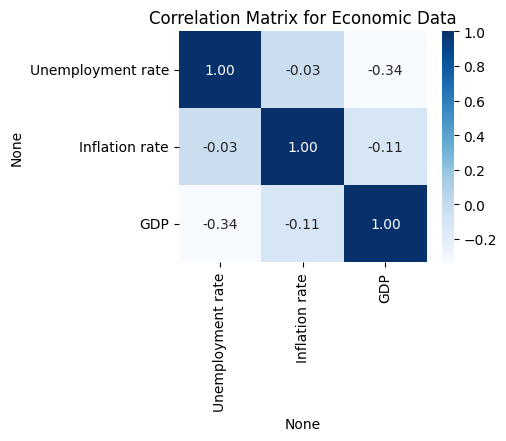

In [227]:
# Correlation matrix for economic data
economic_data = data[['Unemployment rate', 'Inflation rate', 'GDP']]
correlation_matrix = economic_data.corr()
plt.figure(figsize=(4, 3))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix for Economic Data")
plt.show()

#### Exploring the academic data

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
    <tr><td rowspan="5" style="border:1px solid #ccc;padding:6px;text-align:left;">Academic data at enrollment</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Application mode</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Application order</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Ordinal</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Course</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Daytime/evening attendance</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Previous qualification</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>

</tbody>
</table>

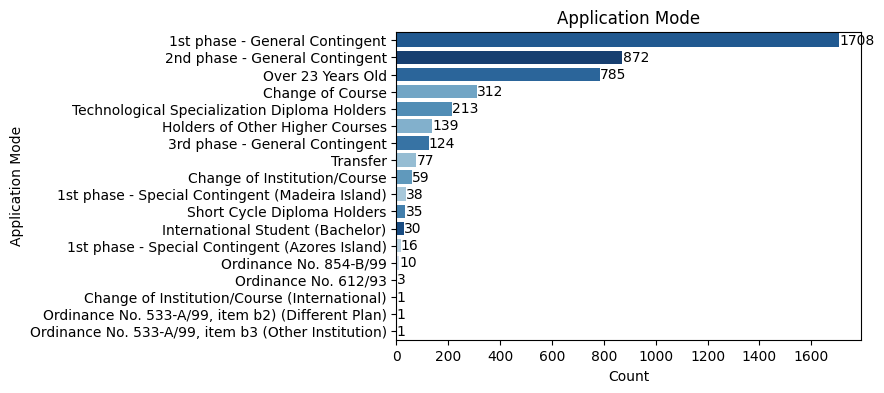

In [228]:
# Plot for Application mode
mapped_data = data[["Application mode"]].iloc[:,0].astype(int).map(application_mode_json)

# sort according to counts
order = mapped_data.value_counts(ascending=False).index

plt.figure(figsize=(6, 4))
sns.countplot(
    y=mapped_data,
    hue=mapped_data,  # assign to hue
    palette="Blues_r",
    legend=False,
    order=order
)
plt.title("Application Mode")
plt.xlabel("Count")
plt.ylabel("Application Mode")
# Show exact counts on bars
for p in plt.gca().patches:
    plt.text(
        p.get_width() + 0.3,
        p.get_y() + p.get_height() / 2,
        int(p.get_width()),
        va='center'
    )
plt.show()

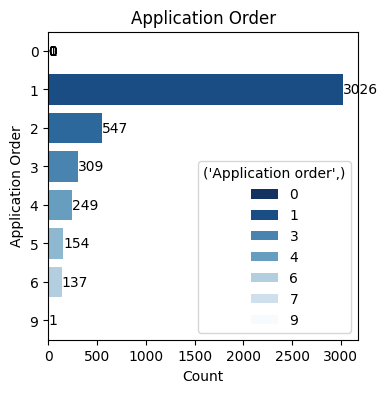

In [230]:
# Plot for Application order

# Convert to numeric and get sorted order
app_order = data[["Application order"]].iloc[:,0].astype(int)
order = app_order.value_counts().sort_index().index  # sort by category value

plt.figure(figsize=(4, 4))
sns.countplot(
    y=app_order,
    hue=app_order,          # assign to hue
    order=order,           # ensure sorted order
    palette="Blues_r"
)

plt.title("Application Order")
plt.xlabel("Count")
plt.ylabel("Application Order")

# Show exact counts on bars
for p in plt.gca().patches:
    plt.text(
        p.get_width() + 0.3,
        p.get_y() + p.get_height() / 2,
        int(p.get_width()),
        va='center'
    )

plt.show()


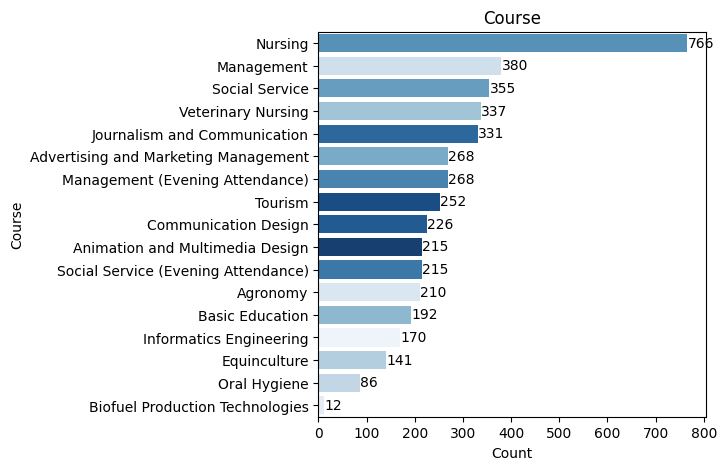

In [232]:
# Plot for Course
mapped_data = data[["Course"]].iloc[:,0].astype(int).map(course_json)
# sort according to counts
order = mapped_data.value_counts(ascending=False).index
plt.figure(figsize=(5, 5))
sns.countplot(
    y=mapped_data,
    hue=mapped_data,  # assign to hue
    palette="Blues_r",
    legend=False,
    order=order
)
plt.title("Course")
plt.xlabel("Count")
plt.ylabel("Course")
# Show exact counts on bars
for p in plt.gca().patches:
    plt.text(
        p.get_width() + 0.3,
        p.get_y() + p.get_height() / 2,
        int(p.get_width()),
        va='center'
    )
plt.show()

In [234]:
# show percentage of Daytime/evening attendance
data['Daytime/evening attendance'].iloc[:,0].map({1: 'Daytime', 0: 'Evening'}).value_counts(normalize=True) * 100

(Daytime/evening attendance,)
Daytime    89.082278
Evening    10.917722
Name: proportion, dtype: float64

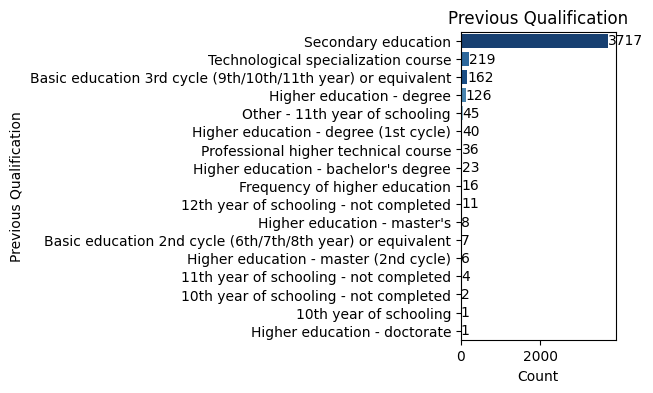

In [240]:
# Plot for Previous qualification
mapped_data = data[["Previous qualification"]].iloc[:,0].astype(int).map(previous_qualification_json)
# sort according to counts
order = mapped_data.value_counts(ascending=True).index
plt.figure(figsize=(2, 4))
sns.countplot(
    y=mapped_data,
    hue=mapped_data,  # assign to hue
    palette="Blues_r",
    legend=False,
    order=order
)
plt.title("Previous Qualification")
plt.xlabel("Count")
plt.ylabel("Previous Qualification")
# Show exact counts on bars
for p in plt.gca().patches:
    plt.text(
        p.get_width() + 0.3,
        p.get_y() + p.get_height() / 2,
        int(p.get_width()),
        va='center'
    )
plt.gca().invert_yaxis()
plt.show()

#### Exploring the Academic data

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
<tr><td rowspan="6" style="border:1px solid #ccc;padding:6px;text-align:left;">Academic data at the end of 1st semester</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (credited)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (enrolled)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (evaluations)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (approved)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (grade)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Continuous</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (without evaluations)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>


</tbody>
</table>

---

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
      <tr><td rowspan="6" style="border:1px solid #ccc;padding:6px;text-align:left;">Academic data at the end of 2nd semester</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (credited)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (enrolled)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (evaluations)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (approved)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (grade)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Continuous</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (without evaluations)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
   </tbody>
</table>

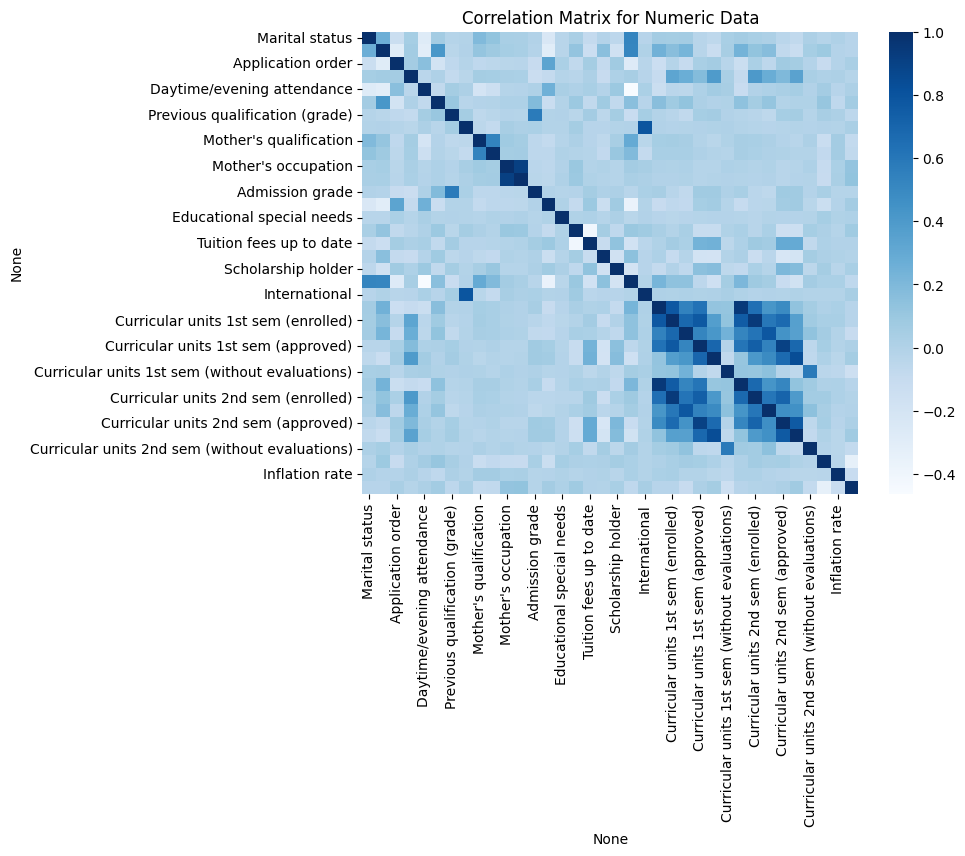

In [244]:
# Correlation matrix for numeric data
numeric_data = data.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=False, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix for Numeric Data")
plt.show()

## Correlation Analysis (Pearson)

**Metric used:** *Pearson correlation coefficient*  
$$
r_{X,Y}=\frac{\operatorname{Cov}(X,Y)}{\sigma_X \sigma_Y},\qquad -1 \le r \le 1
$$

- **r = 1**: perfect positive correlation (as one increases, the other increases).  
- **r = 0**: no linear correlation.  
- **r = −1**: perfect negative correlation (as one increases, the other decreases).

### Reading the Heatmap
- **Color encodes correlation strength**: darker shades → higher |r|.  
- **Diagonal cells** are always **1.0** (a variable correlated with itself).  
- **Blocks/tiles** of similar color reveal groups of variables that move together.

---

### Key Observations

#### 1) Clusters of Strong Correlation
- **Curricular units (1st & 2nd semester: enrolled, credited, approved, evaluations, grade)** show **strong positive correlations** with each other (deep blue block).
- **Example:** Students who **enroll in more units** tend to **complete/approve more** and achieve higher **evaluation activity**, indicating these features move together.
- **Implication:** Possible **feature redundancy** (collinearity) — consider dimensionality reduction or careful feature selection.

#### 2) Weak Correlations with Demographics
- **Marital status, Father’s occupation, Nationality, Gender** show **very light shades**, indicating **weak correlations** with most variables.
- **Implication:** These are likely **weaker predictors** than academic performance features.

#### 3) Moderate Correlations
- **Admission grade** correlates with **curricular performance** (sensible academic relationship).
- **Tuition fees up to date** correlates with **Debtor** status (administrative consistency).

#### 4) Macroeconomic Variables
- **Unemployment rate, Inflation, GDP** show **very light correlations**, suggesting **limited direct impact** on individual-level academic variables in this dataset.

---



In this dataset, not all features are equally useful for predicting student **dropout risk**.  
We analyze feature importance based on **correlation, domain knowledge, and interpretability**.




### 1. Academic Performance (Strong Predictors)
- **Admission grade** → Higher admission grades generally correlate with persistence.  
- **Curricular units (1st & 2nd semester):**
  - Enrolled  
  - Credited  
  - Approved  
  - Evaluations  
  - Grades  

 *These features reflect early engagement and performance. Students who fail or don’t complete their first-year courses are more likely to drop out.*



### 2. Financial / Administrative Indicators
- **Debtor status** → If a student owes tuition, dropout risk increases.  
- **Tuition fees up to date** → Strong correlation with financial stability.  
- **Scholarship holder** → May reduce dropout risk since financial aid eases pressure.  


### 3. Demographic & Background Factors
- **Age at enrollment** → Older students may face higher dropout risk due to responsibilities.  
- **Mother’s/Father’s qualification** → Proxy for educational support at home.  
- **Displaced / International status** → May affect retention if adaptation is difficult.  
- **Educational special needs** → Students may require additional support.  



### 4. Behavioral & Engagement Features
- **Application mode & application order** → Can reflect motivation and decision-making process.  
- **Daytime/Evening attendance** → Evening students may juggle work/family, influencing dropout risk.  



## Less Useful Features
These features show **very weak correlations** and limited predictive value:  
- **Marital status**  
- **Nationality** (unless context-specific)  
- **Father’s occupation / Mother’s occupation**  
- **Macroeconomic indicators (Unemployment rate, Inflation, GDP)** → Too aggregated to explain individual dropout risk.  



### Recommended Feature Set
To predict the dropout we consider below features-

1. Admission grade
2. Curricular units (1st & 2nd semester: enrolled, credited, approved, evaluations, grade)
3. Debtor status  
4. Tuition fees up to date 
5. Scholarship holder  
6. Age at enrollment  
7. Educational special needs  
8. Displaced / International status  
9. Application mode & order  
10. Daytime/Evening attendance



### Key Takeaway
Academic performance + financial stability are the **strongest predictors** of student dropout.  
Demographics and background factors add context but are **weaker signals** compared to **grades and engagement**.


In [245]:
data_selected = data[["Daytime/evening attendance", "Admission grade", 
                      "Displaced", "Educational special needs", "Debtor", "Tuition fees up to date", 
                 "Scholarship holder", "Age at enrollment", "International", 
                 
                 "Curricular units 1st sem (credited)",
                 "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (evaluations)",
                 "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
                 "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
                 "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
                 "Curricular units 2nd sem (grade)", 
                 
                 "Target"]]

In [246]:
data_selected['Target'].value_counts()

(Target,)
Graduate     2209
Dropout      1421
Enrolled      794
Name: count, dtype: int64

In [247]:
data_selected.head()

,Daytime/evening attendance,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Target
0,1,127.3,1,0,0,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0.000000,Dropout
1,1,142.5,1,0,0,0,0,19,0,0,6,6,6,14.000000,0,6,6,6,13.666667,Graduate
2,1,124.8,1,0,0,0,0,19,0,0,6,0,0,0.000000,0,6,0,0,0.000000,Dropout
3,1,119.6,1,0,0,1,0,20,0,0,6,8,6,13.428571,0,6,10,5,12.400000,Graduate
4,0,141.5,0,0,0,1,0,45,0,0,6,9,5,12.333333,0,6,6,6,13.000000,Graduate


In [248]:
data_selected.shape

(4424, 20)

In [249]:
# Prepare the data for SMOTE
# First separate features and target
X = data_selected.drop('Target', axis=1)
y = data_selected['Target']

/tmp/ipykernel_3657659/2158402430.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X = data_selected.drop('Target', axis=1)


In [250]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [251]:
# Scale the features before applying SMOTE
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training set & transform
X_train_scaled = scaler.fit_transform(X_train)

# Use the same transformation on test set
X_test_scaled = scaler.transform(X_test)


In [252]:
# Apply SMOTE to training data only
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [253]:
# Print class distribution before and after SMOTE
print("Original class distribution in training set:")
print(y_train.value_counts(), "\n")

print("Class distribution after SMOTE:")
print(y_train_resampled["Target"].value_counts())

Original class distribution in training set:
(Target,)
Graduate     1767
Dropout      1137
Enrolled      635
Name: count, dtype: int64 

Class distribution after SMOTE:
(Target,)
Dropout      1767
Enrolled     1767
Graduate     1767
Name: count, dtype: int64


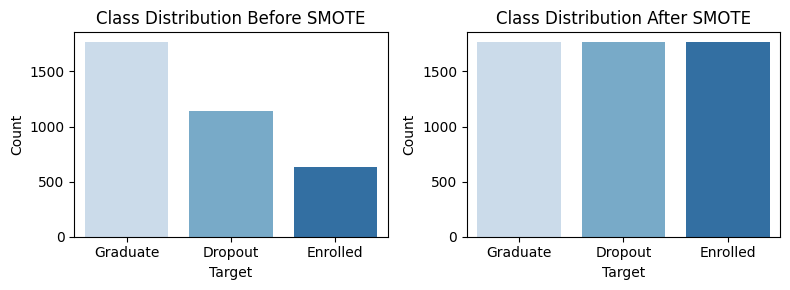

In [257]:
# Assuming y_train is a DataFrame with one column "Target"
y_train_series = y_train.iloc[:, 0]
y_train_resampled_series = y_train_resampled.iloc[:, 0]

# Visualize class distribution before and after SMOTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# Before SMOTE
sns.countplot(x=y_train_series, ax=ax1, hue=y_train_series, palette='Blues')
ax1.set_title('Class Distribution Before SMOTE')
ax1.set_xlabel('Target')
ax1.set_ylabel('Count')

# After SMOTE
sns.countplot(x=y_train_resampled_series, ax=ax2, hue=y_train_resampled_series, palette='Blues')
ax2.set_title('Class Distribution After SMOTE')
ax2.set_xlabel('Target')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()


In [258]:
# Store the resampled data for later use
train_resampled = pd.DataFrame(X_train_resampled, columns=X.columns)
train_resampled['Target'] = y_train_resampled

### Lets apply Multinomail Logistic Regression to predict student dropout using the selected features.


In [259]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [260]:
# Train Multinomial Logistic Regression on the resampled data
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)

/media/pc/disk/PhD/CS698Y Human AI-Interaction/Assignment 2/CS698Y-assignment2/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/media/pc/disk/PhD/CS698Y Human AI-Interaction/Assignment 2/CS698Y-assignment2/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [261]:
# Make predictions on test set
y_pred = lr_model.predict(X_test_scaled)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.68      0.75       284
    Enrolled       0.41      0.62      0.49       159
    Graduate       0.85      0.79      0.82       442

    accuracy                           0.73       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.73      0.74       885



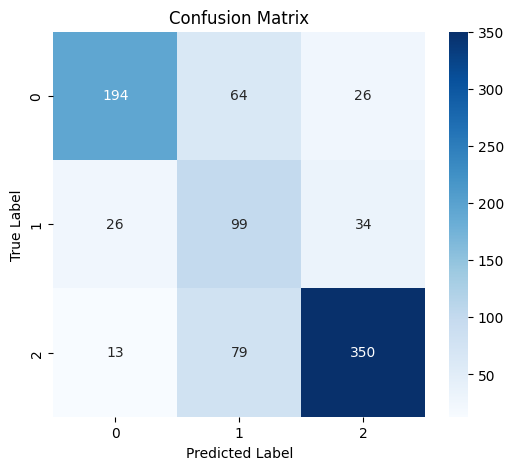

In [264]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [265]:
# Get feature importance
# Fix the column names by flattening the nested list
feature_names = [col[0] if isinstance(col, list) else col for col in X.columns]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.mean(np.abs(lr_model.coef_), axis=0)
})

# Sort features by importance
feature_importance = feature_importance.sort_values('Importance', ascending=False)

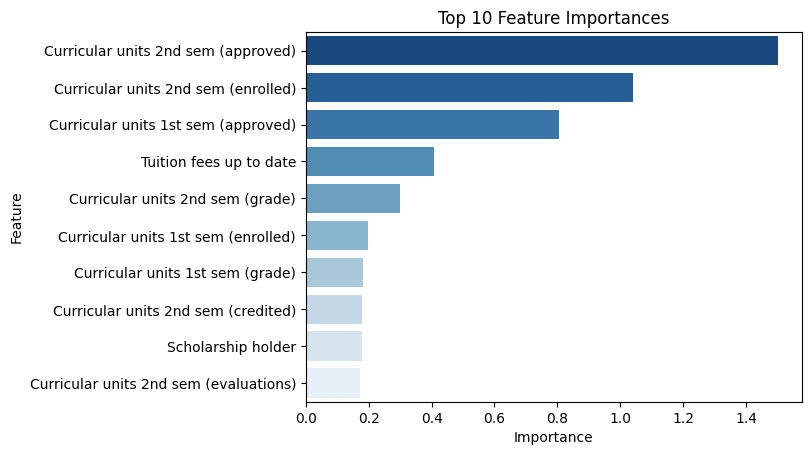

In [266]:
# Fix tuple formatting in Feature column
feature_importance['Feature'] = feature_importance['Feature'].apply(lambda x: x[0] if isinstance(x, tuple) else x)

# Plot
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10),
    hue='Feature',
    palette='Blues_r'
)
plt.title("Top 10 Feature Importances")
plt.show()


In [267]:
# Print model accuracy on test set
print(f"\nModel Accuracy on Test Set: {lr_model.score(X_test_scaled, y_test):.3f}")

# Get class probabilities for a few examples
proba = lr_model.predict_proba(X_test_scaled[:5])
print("\nProbability predictions for first 5 test samples:")
print(pd.DataFrame(proba, columns=lr_model.classes_))


Model Accuracy on Test Set: 0.727

Probability predictions for first 5 test samples:
    Dropout  Enrolled  Graduate
0  0.027748  0.136824  0.835428
1  0.020462  0.193710  0.785828
2  0.845753  0.153972  0.000275
3  0.023833  0.094916  0.881251
4  0.021640  0.105849  0.872511


In [268]:
# Lets try for Decision Tree Classifier# Import necessary libraries for Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [269]:
# Initialize and train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_resampled, y_train_resampled)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [270]:
# Make predictions
dt_pred = dt_model.predict(X_test_scaled)

# Print model performance metrics
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Classification Report:
              precision    recall  f1-score   support

     Dropout       0.86      0.62      0.72       284
    Enrolled       0.35      0.66      0.46       159
    Graduate       0.84      0.73      0.78       442

    accuracy                           0.68       885
   macro avg       0.69      0.67      0.65       885
weighted avg       0.76      0.68      0.70       885



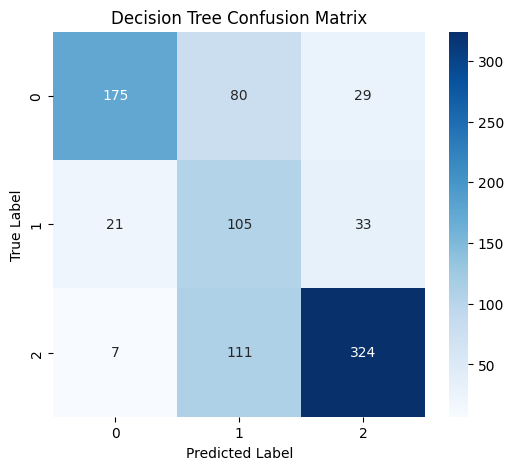

In [271]:
# Create and plot confusion matrix
plt.figure(figsize=(6,5))
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

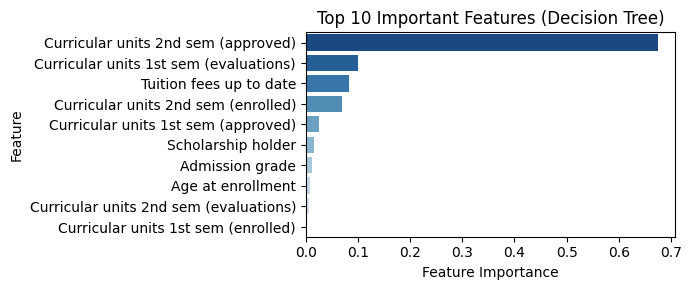

In [274]:
# Get feature importances
dt_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

# Sort by importance
dt_feature_importance = dt_feature_importance.sort_values('Importance', ascending=False)

dt_feature_importance['Feature'] = dt_feature_importance['Feature'].apply(lambda x: x[0] if isinstance(x, tuple) else x)

# Plot feature importances
plt.figure(figsize=(7, 3))
sns.barplot(
    data=dt_feature_importance.head(10),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='Blues_r'
)
plt.title('Top 10 Important Features (Decision Tree)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

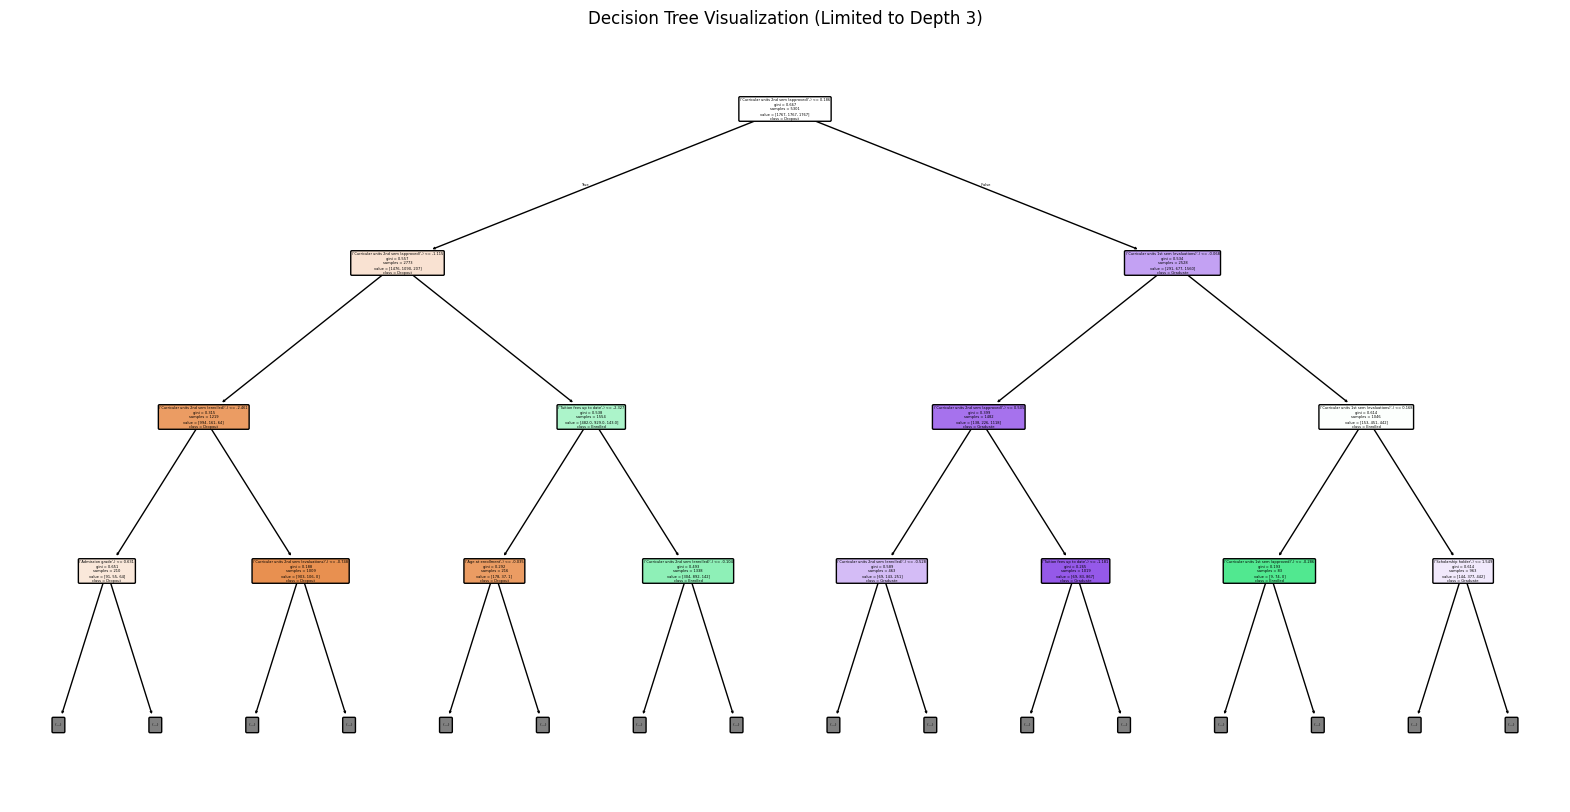

In [275]:
# Visualize the decision tree (limited to max_depth=3 for better visualization)
plt.figure(figsize=(20,10))
plot_tree(dt_model, max_depth=3, feature_names=X.columns, 
          class_names=dt_model.classes_, filled=True, rounded=True)
plt.title('Decision Tree Visualization (Limited to Depth 3)')
plt.show()

In [277]:
# Import accuracy_score
from sklearn.metrics import accuracy_score

# Print model accuracy
print(f"\nDecision Tree Accuracy on Test Set: {accuracy_score(y_test, dt_pred):.3f}")


Decision Tree Accuracy on Test Set: 0.682


In [278]:
# Compare probabilities for first few samples
dt_proba = dt_model.predict_proba(X_test_scaled[:5])
print("\nProbability predictions for first 5 test samples (Decision Tree):")
print(pd.DataFrame(dt_proba, columns=dt_model.classes_))


Probability predictions for first 5 test samples (Decision Tree):
    Dropout  Enrolled  Graduate
0  0.062124  0.077154  0.860721
1  0.152886  0.485179  0.361934
2  0.746429  0.253571  0.000000
3  0.054945  0.098901  0.846154
4  0.062124  0.077154  0.860721


In [279]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,  # number of trees
    max_depth=10,      # maximum depth of trees
    random_state=42,   # for reproducibility
    n_jobs=-1         # use all available cores
)

In [280]:
# Train the model on resampled data
rf_model.fit(X_train_resampled, y_train_resampled)

/media/pc/disk/PhD/CS698Y Human AI-Interaction/Assignment 2/CS698Y-assignment2/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [281]:
# Make predictions
rf_pred = rf_model.predict(X_test_scaled)

# Print model performance metrics
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

     Dropout       0.85      0.68      0.75       284
    Enrolled       0.45      0.60      0.51       159
    Graduate       0.83      0.84      0.84       442

    accuracy                           0.74       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.77      0.74      0.75       885



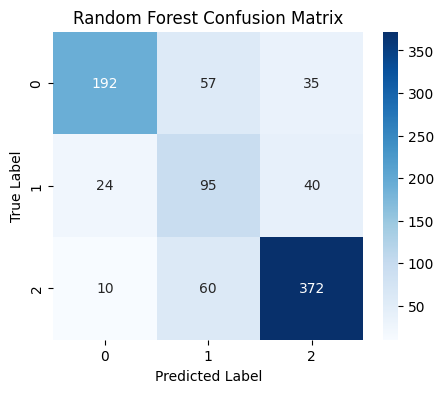

In [282]:
# Create and plot confusion matrix
plt.figure(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

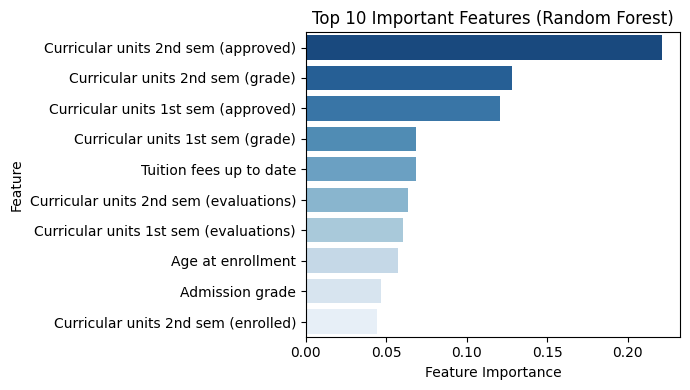

In [285]:
# Get feature importances
rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
rf_feature_importance = rf_feature_importance.sort_values('Importance', ascending=False)

# Clean up feature names
rf_feature_importance['Feature'] = rf_feature_importance['Feature'].apply(
    lambda x: x[0] if isinstance(x, tuple) else x
)

# Plot feature importances
plt.figure(figsize=(7, 4))
sns.barplot(
    data=rf_feature_importance.head(10),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='Blues_r'
)
plt.title('Top 10 Important Features (Random Forest)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

In [286]:
# Print model accuracy
print(f"\nRandom Forest Accuracy on Test Set: {accuracy_score(y_test, rf_pred):.3f}")

# Compare probabilities for first few samples
rf_proba = rf_model.predict_proba(X_test_scaled[:5])
print("\nProbability predictions for first 5 test samples (Random Forest):")
print(pd.DataFrame(rf_proba, columns=rf_model.classes_))


Random Forest Accuracy on Test Set: 0.745

Probability predictions for first 5 test samples (Random Forest):
    Dropout  Enrolled  Graduate
0  0.054069  0.027613  0.918318
1  0.058061  0.302411  0.639528
2  0.874359  0.125641  0.000000
3  0.046408  0.085813  0.867779
4  0.058017  0.099296  0.842687


In [287]:
# Calculate performance metrics for Random Forest
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

# Calculate precision, recall, and f1-score for each class
precision, recall, f1, _ = precision_recall_fscore_support(y_test, rf_pred, average=None)

# Create a DataFrame to display metrics by class
metrics_df = pd.DataFrame({
    'Class': rf_model.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
})

# Calculate weighted averages
weighted_precision = precision_recall_fscore_support(y_test, rf_pred, average='weighted')[0]
weighted_recall = precision_recall_fscore_support(y_test, rf_pred, average='weighted')[1]
weighted_f1 = precision_recall_fscore_support(y_test, rf_pred, average='weighted')[2]

In [288]:
# Print results
print("Random Forest Performance Metrics:\n")
print(f"Overall Accuracy: {rf_accuracy:.4f}\n")
print("Metrics by Class:")
print(metrics_df.to_string(index=False))
print("\nWeighted Averages:")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

Random Forest Performance Metrics:

Overall Accuracy: 0.7446

Metrics by Class:
   Class  Precision   Recall  F1-score
 Dropout   0.849558 0.676056  0.752941
Enrolled   0.448113 0.597484  0.512129
Graduate   0.832215 0.841629  0.836895

Weighted Averages:
Weighted Precision: 0.7688
Weighted Recall: 0.7446
Weighted F1-score: 0.7516


In [289]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [290]:
# Initialize and train Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,    # number of boosting stages
    learning_rate=0.1,   # shrinks the contribution of each tree
    max_depth=5,         # maximum depth of individual trees
    random_state=42,
    subsample=0.8        # fraction of samples for fitting base learners
)

In [291]:
# Train the model on resampled data
gb_model.fit(X_train_resampled, y_train_resampled)

/media/pc/disk/PhD/CS698Y Human AI-Interaction/Assignment 2/CS698Y-assignment2/venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [292]:
# Make predictions
gb_pred = gb_model.predict(X_test_scaled)

# Print classification report
print("Gradient Boosting Classification Report:")
print(classification_report(y_test, gb_pred))

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

     Dropout       0.81      0.74      0.77       284
    Enrolled       0.47      0.53      0.50       159
    Graduate       0.84      0.86      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.71      0.71       885
weighted avg       0.77      0.76      0.76       885



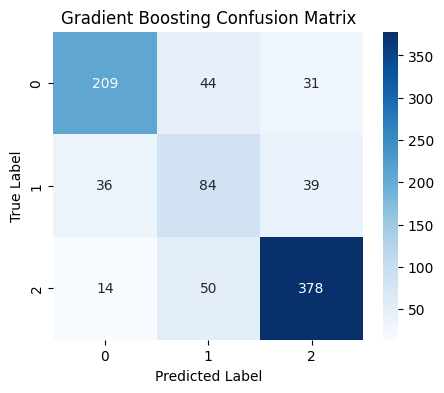

In [293]:
# Create and plot confusion matrix
plt.figure(figsize=(5, 4))
cm_gb = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.title('Gradient Boosting Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

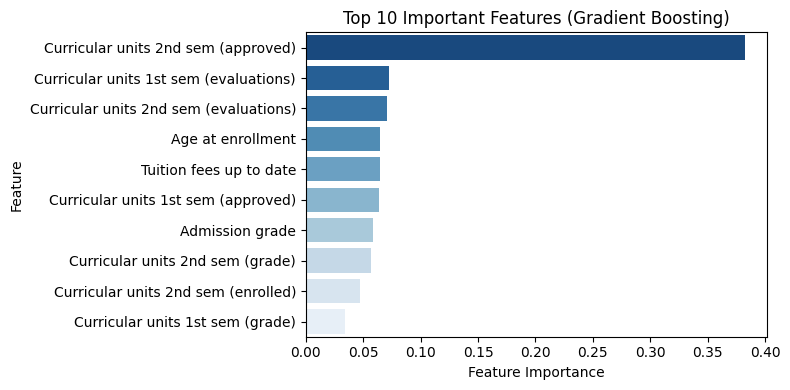

In [296]:
# Get feature importances
gb_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})

# Sort by importance
gb_feature_importance = gb_feature_importance.sort_values('Importance', ascending=False)

# Clean up feature names
gb_feature_importance['Feature'] = gb_feature_importance['Feature'].apply(
    lambda x: x[0] if isinstance(x, tuple) else x
)

# Plot feature importances
plt.figure(figsize=(8, 4))
sns.barplot(
    data=gb_feature_importance.head(10),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='Blues_r'
)
plt.title('Top 10 Important Features (Gradient Boosting)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

In [297]:
# Calculate detailed performance metrics
gb_accuracy = accuracy_score(y_test, gb_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, gb_pred, average=None)

# Create metrics DataFrame
metrics_df = pd.DataFrame({
    'Class': gb_model.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
})

# Calculate weighted averages
weighted_precision = precision_recall_fscore_support(y_test, gb_pred, average='weighted')[0]
weighted_recall = precision_recall_fscore_support(y_test, gb_pred, average='weighted')[1]
weighted_f1 = precision_recall_fscore_support(y_test, gb_pred, average='weighted')[2]

In [298]:
# Print results
print("\nGradient Boosting Performance Metrics:\n")
print(f"Overall Accuracy: {gb_accuracy:.4f}\n")
print("Metrics by Class:")
print(metrics_df.to_string(index=False))
print("\nWeighted Averages:")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")


Gradient Boosting Performance Metrics:

Overall Accuracy: 0.7582

Metrics by Class:
   Class  Precision   Recall  F1-score
 Dropout    0.80695 0.735915  0.769797
Enrolled    0.47191 0.528302  0.498516
Graduate    0.84375 0.855204  0.849438

Weighted Averages:
Weighted Precision: 0.7651
Weighted Recall: 0.7582
Weighted F1-score: 0.7608


In [300]:
# Ensure y is 1D
y_train_resampled = y_train_resampled.values.ravel()
y_test = y_test.values.ravel()

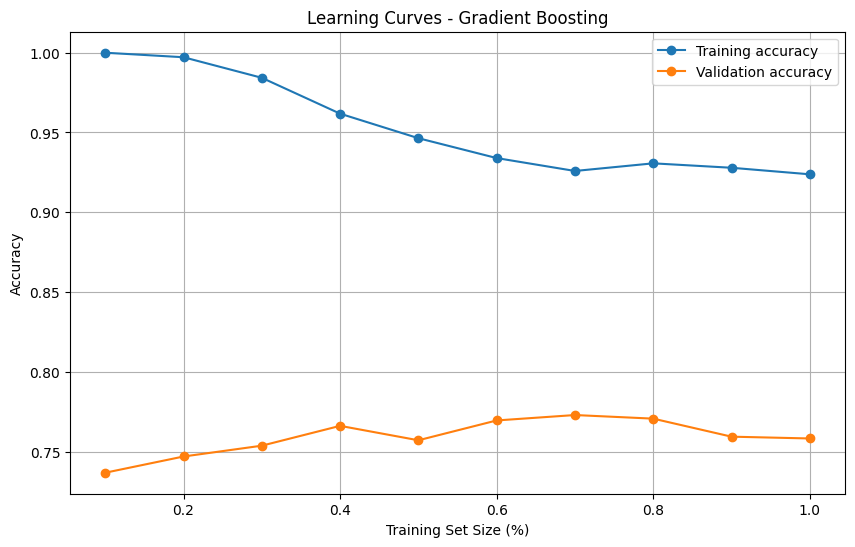

In [301]:
# Plot learning curves
train_scores = []
val_scores = []
train_sizes = np.linspace(0.1, 1.0, 10)

for size in train_sizes:
    n_samples = int(len(X_train_resampled) * size)
    
    # Train model on subset
    gb_model.fit(X_train_resampled[:n_samples], y_train_resampled[:n_samples])
    
    # Calculate scores
    train_scores.append(
        accuracy_score(y_train_resampled[:n_samples],
                       gb_model.predict(X_train_resampled[:n_samples]))
    )
    val_scores.append(
        accuracy_score(y_test, gb_model.predict(X_test_scaled))
    )

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores, label='Training accuracy', marker='o')
plt.plot(train_sizes, val_scores, label='Validation accuracy', marker='o')
plt.xlabel('Training Set Size (%)')
plt.ylabel('Accuracy')
plt.title('Learning Curves - Gradient Boosting')
plt.legend()
plt.grid(True)
plt.show()


In [302]:
# Import necessary libraries
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, accuracy_score, precision_recall_fscore_support

# Define the 5-fold cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [303]:
# Function to perform cross validation and return detailed metrics
def cross_validate_model(model, X, y, cv=kfold):
    # Convert DataFrames to numpy arrays if needed
    X_array = X if isinstance(X, np.ndarray) else X.to_numpy()
    y_array = y if isinstance(y, np.ndarray) else y.to_numpy()
    
    # Get accuracy scores
    accuracy_scores = cross_val_score(model, X_array, y_array, cv=cv, scoring='accuracy')
    
    # Get precision, recall, f1 scores for each fold
    precision_scores = []
    recall_scores = []
    f1_scores = []
    
    for train_idx, val_idx in cv.split(X_array, y_array):
        # Use arrays for indexing
        X_train_fold, X_val_fold = X_array[train_idx], X_array[val_idx]
        y_train_fold, y_val_fold = y_array[train_idx], y_array[val_idx]
        
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)
        
        # Calculate metrics for this fold
        precision, recall, f1, _ = precision_recall_fscore_support(y_val_fold, y_pred, average='weighted')
        
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
    
    return {
        'accuracy': accuracy_scores,
        'precision': precision_scores,
        'recall': recall_scores,
        'f1': f1_scores
    }

In [ ]:
# Make sure y is 1D
y_train_resampled = y_train_resampled.ravel()

# Apply cross validation to all models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(solver='lbfgs', max_iter=1000)  # default to multinomial
}

# Store results for each model
cv_results = {}

for name, model in models.items():
    print(f"\nPerforming 5-fold cross validation for {name}...")
    metrics = cross_validate_model(model, X_train_resampled, y_train_resampled)
    cv_results[name] = metrics
    
    # Print results
    print(f"\n{name} Cross-Validation Results:")
    print(f"Accuracy: {metrics['accuracy'].mean():.4f} (+/- {metrics['accuracy'].std() * 2:.4f})")
    print(f"Precision: {np.mean(metrics['precision']):.4f} (+/- {np.std(metrics['precision']) * 2:.4f})")
    print(f"Recall: {np.mean(metrics['recall']):.4f} (+/- {np.std(metrics['recall']) * 2:.4f})")
    print(f"F1-score: {np.mean(metrics['f1']):.4f} (+/- {np.std(metrics['f1']) * 2:.4f})")

# Visualize cross-validation results
plt.figure(figsize=(8, 5))
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics))
width = 0.25

for i, (name, results) in enumerate(cv_results.items()):
    means = [np.mean(results[metric]) for metric in metrics]
    plt.bar(x + i*width, means, width, label=name)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Cross-Validation Results Comparison')
plt.xticks(x + width, metrics)
plt.legend()
plt.tight_layout()
plt.show()



Performing 5-fold cross validation for Random Forest...

Random Forest Cross-Validation Results:
Accuracy: 0.7976 (+/- 0.0174)
Precision: 0.8051 (+/- 0.0184)
Recall: 0.7976 (+/- 0.0174)
F1-score: 0.7978 (+/- 0.0185)

Performing 5-fold cross validation for Gradient Boosting...
